In [3]:
import matplotlib.pyplot as plt

import geomstats.backend as gs

gs.random.seed(2021)

In [4]:
import geomstats.datasets.utils as data_utils

cells, lines, treatments = data_utils.load_cells()
print(f"Total number of cells : {len(cells)}")

Total number of cells : 650


In [5]:
import pandas as pd

TREATMENTS = gs.unique(treatments)
print(TREATMENTS)
LINES = gs.unique(lines)
print(LINES)

['control' 'cytd' 'jasp']
['dlm8' 'dunn']


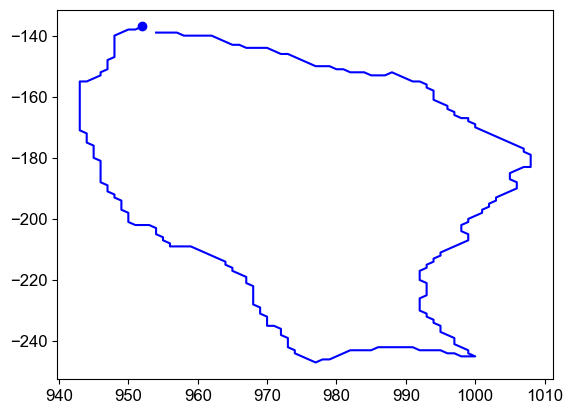

In [6]:
cell_idx = 1
plt.plot(cells[cell_idx][:, 0], cells[cell_idx][:, 1], "blue")
plt.plot(cells[cell_idx][0, 0], cells[cell_idx][0, 1], "blue", marker="o");

In [7]:
ds = {}

n_cells_arr = gs.zeros((3, 2))

for i, treatment in enumerate(TREATMENTS):
    print(f"{treatment} :")
    ds[treatment] = {}
    for j, line in enumerate(LINES):
        to_keep = gs.array(
            [
                one_treatment == treatment and one_line == line
                for one_treatment, one_line in zip(treatments, lines)
            ]
        )
        ds[treatment][line] = [
            cell_i for cell_i, to_keep_i in zip(cells, to_keep) if to_keep_i
        ]
        nb = len(ds[treatment][line])
        print(f"\t {nb} {line}")
        n_cells_arr[i, j] = nb

n_cells_df = pd.DataFrame({"dlm8": n_cells_arr[:, 0], "dunn": n_cells_arr[:, 1]})
n_cells_df = n_cells_df.set_index(TREATMENTS)

display(n_cells_df)
# display(ds)

control :
	 114 dlm8
	 204 dunn
cytd :
	 82 dlm8
	 93 dunn
jasp :
	 62 dlm8
	 95 dunn


,dlm8,dunn
control,114.0,204.0
cytd,82.0,93.0
jasp,62.0,95.0


In [8]:
len(ds["cytd"]["dlm8"])

82

In [9]:
def apply_func_to_ds(input_ds, func):
    """Apply the input function func to the input dictionnary input_ds.

    This function goes through the dictionnary structure and applies
    func to every cell in input_ds[treatment][line].

    It stores the result in a dictionnary output_ds that is returned
    to the user.

    Parameters
    ----------
    input_ds : dict
        Input dictionnary, with keys treatment-line.
    func : callable
        Function to be applied to the values of the dictionnary, i.e.
        the cells.

    Returns
    -------
    output_ds : dict
        Output dictionnary, with the same keys as input_ds.
    """
    output_ds = {}
    for treatment in TREATMENTS:
        output_ds[treatment] = {}
        for line in LINES:
            output_list = []
            for one_cell in input_ds[treatment][line]:
                output_list.append(func(one_cell))
            output_ds[treatment][line] = gs.array(output_list)
    return output_ds

In [10]:
def interpolate(curve, nb_points):
    """Interpolate a discrete curve with nb_points from a discrete curve.

    Returns
    -------
    interpolation : discrete curve with nb_points points
    """
    old_length = curve.shape[0]
    interpolation = gs.zeros((nb_points, 2))
    incr = old_length / nb_points
    pos = 0
    for i in range(nb_points):
        index = int(gs.floor(pos))
        interpolation[i] = curve[index] + (pos - index) * (
            curve[(index + 1) % old_length] - curve[index]
        )
        pos += incr
    return interpolation


k_sampling_points = 200

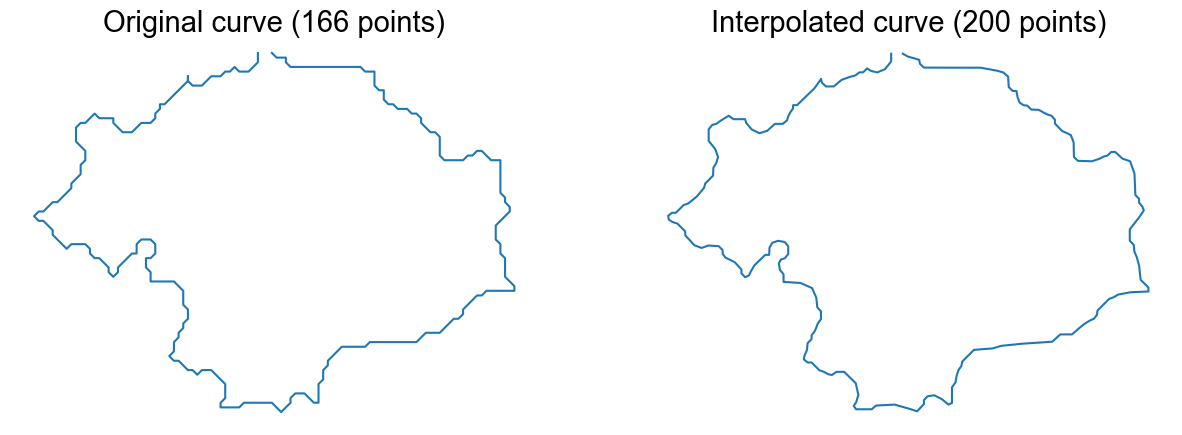

In [11]:
cell_rand = cells[gs.random.randint(len(cells))]
cell_interpolation = interpolate(cell_rand, k_sampling_points)

fig = plt.figure(figsize=(15, 5))

fig.add_subplot(121)
plt.plot(cell_rand[:, 0], cell_rand[:, 1])
plt.axis("equal")
plt.title(f"Original curve ({len(cell_rand)} points)")
plt.axis("off")

fig.add_subplot(122)
plt.plot(cell_interpolation[:, 0], cell_interpolation[:, 1])
plt.axis("equal")
plt.title(f"Interpolated curve ({k_sampling_points} points)")
plt.axis("off")

plt.savefig("interpolation.svg")

In [12]:
ds_interp = apply_func_to_ds(
    input_ds=ds, func=lambda x: interpolate(x, k_sampling_points)
)

In [13]:
print(ds_interp["control"]["dunn"].shape)

(204, 200, 2)


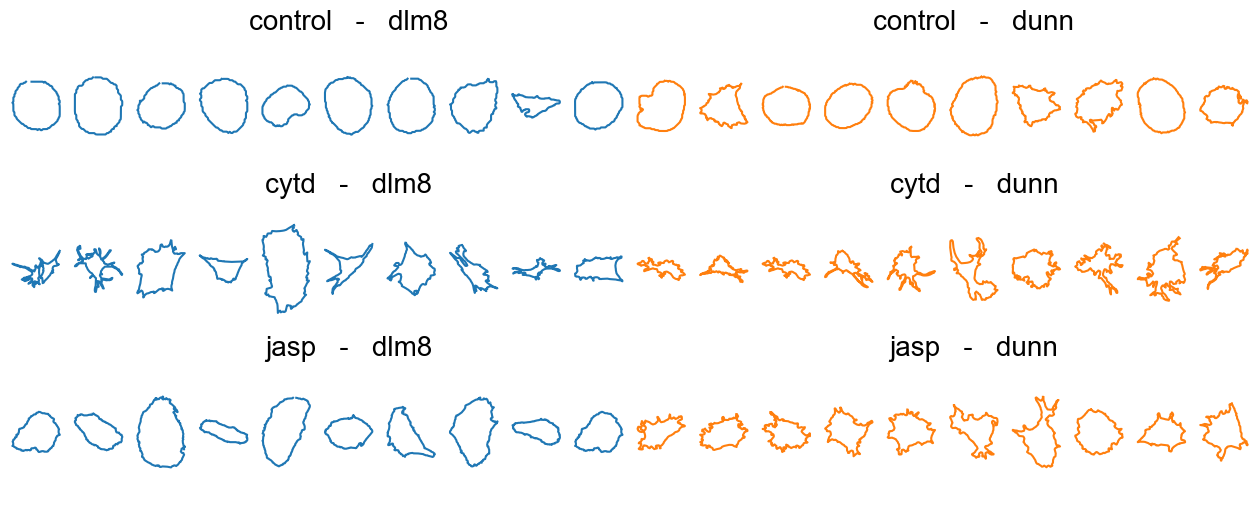

In [14]:
n_cells_to_plot = 10

fig = plt.figure(figsize=(16, 6))
count = 1
for treatment in TREATMENTS:
    for line in LINES:
        cell_data = ds_interp[treatment][line]
        for i_to_plot in range(n_cells_to_plot):
            cell = gs.random.choice(cell_data)
            fig.add_subplot(3, 2 * n_cells_to_plot, count)
            count += 1
            plt.plot(cell[:, 0], cell[:, 1], color="C" + str(int((line == "dunn"))))
            plt.axis("equal")
            plt.axis("off")
            if i_to_plot == n_cells_to_plot // 2:
                plt.title(f"{treatment}   -   {line}", fontsize=20)
plt.savefig("cancer_cell_sample.svg")

In [15]:
import numpy as np


def preprocess(curve, tol=1e-10):
    """Preprocess curve to ensure that there are no consecutive duplicate points.

    Returns
    -------
    curve : discrete curve
    """
    dist = curve[1:] - curve[:-1]
    dist_norm = np.sqrt(np.sum(np.square(dist), axis=1))

    if np.any(dist_norm < tol):
        for i in range(len(curve) - 1):
            if np.sqrt(np.sum(np.square(curve[i + 1] - curve[i]), axis=0)) < tol:
                curve[i + 1] = (curve[i] + curve[i + 2]) / 2

    return curve

In [16]:
from geomstats.geometry.pre_shape import PreShapeSpace

AMBIENT_DIM = 2

PRESHAPE_SPACE = PreShapeSpace(ambient_dim=AMBIENT_DIM, k_landmarks=k_sampling_points)

PRESHAPE_SPACE.equip_with_group_action("rotations")
PRESHAPE_SPACE.equip_with_quotient()


def exhaustive_align(curve, base_curve):
    """Align curve to base_curve to minimize the L² distance.

    Returns
    -------
    aligned_curve : discrete curve
    """
    nb_sampling = len(curve)
    distances = gs.zeros(nb_sampling)
    base_curve = gs.array(base_curve)
    for shift in range(nb_sampling):
        reparametrized = [curve[(i + shift) % nb_sampling] for i in range(nb_sampling)]
        aligned = PRESHAPE_SPACE.fiber_bundle.align(
            point=gs.array(reparametrized), base_point=base_curve
        )
        distances[shift] = PRESHAPE_SPACE.embedding_space.metric.norm(
            gs.array(aligned) - gs.array(base_curve)
        )
    shift_min = gs.argmin(distances)
    reparametrized_min = [
        curve[(i + shift_min) % nb_sampling] for i in range(nb_sampling)
    ]
    aligned_curve = PRESHAPE_SPACE.fiber_bundle.align(
        point=gs.array(reparametrized_min), base_point=base_curve
    )
    return aligned_curve

In [17]:
ds_proc = apply_func_to_ds(ds_interp, func=lambda x: preprocess(x))

ds_proj = apply_func_to_ds(ds_proc, func=PRESHAPE_SPACE.projection)
print(ds_proj["control"]["dunn"].shape)

BASE_CURVE = ds_proj["control"]["dunn"][0]
print("Shape of BASE_CURVE:", BASE_CURVE.shape)

ds_align = apply_func_to_ds(ds_proj, func=lambda x: exhaustive_align(x, BASE_CURVE))
print(ds_align["control"]["dunn"].shape)

(204, 200, 2)
Shape of BASE_CURVE: (200, 2)
(204, 200, 2)


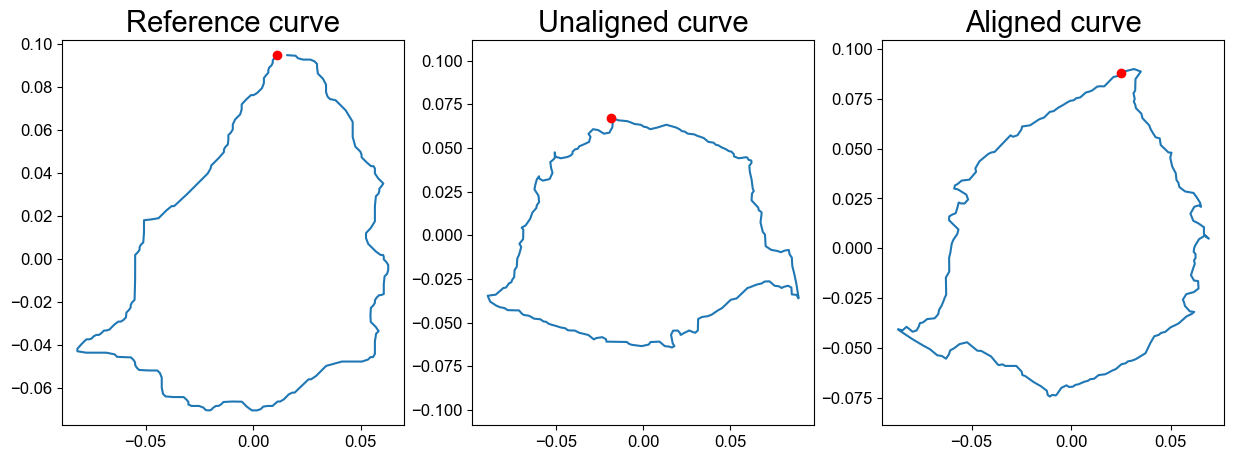

In [18]:
i_rand = gs.random.randint(n_cells_df.loc["control"]["dunn"])
unaligned_cell = ds_proj["control"]["dunn"][i_rand]
aligned_cell = ds_align["control"]["dunn"][i_rand]

fig = plt.figure(figsize=(15, 5))

fig.add_subplot(131)
plt.plot(BASE_CURVE[:, 0], BASE_CURVE[:, 1])
plt.plot(BASE_CURVE[0, 0], BASE_CURVE[0, 1], "ro")
plt.axis("equal")
plt.title("Reference curve")

fig.add_subplot(132)
plt.plot(unaligned_cell[:, 0], unaligned_cell[:, 1])
plt.plot(unaligned_cell[0, 0], unaligned_cell[0, 1], "ro")
plt.axis("equal")
plt.title("Unaligned curve")

fig.add_subplot(133)
plt.plot(aligned_cell[:, 0], aligned_cell[:, 1])
plt.plot(aligned_cell[0, 0], aligned_cell[0, 1], "ro")
plt.axis("equal")
plt.title("Aligned curve")

plt.savefig("alignment.svg")

In [19]:
i_start_rand = gs.random.randint(len(ds_proj["control"]["dunn"]))
i_end_rand = gs.random.randint(len(ds_proj["control"]["dlm8"]))

cell_start = ds_align["control"]["dunn"][i_start_rand]
cell_end = ds_align["control"]["dlm8"][i_end_rand]

print(i_start_rand, i_end_rand)

57 0


In [20]:
from geomstats.geometry.discrete_curves import DiscreteCurvesStartingAtOrigin

CURVES_SPACE_SRV = DiscreteCurvesStartingAtOrigin(ambient_dim=2, k_sampling_points=200)

cell_start_at_origin = CURVES_SPACE_SRV.projection(cell_start)
cell_end_at_origin = CURVES_SPACE_SRV.projection(cell_end)

geodesic_func = CURVES_SPACE_SRV.metric.geodesic(
    initial_point=cell_start_at_origin, end_point=cell_end_at_origin
)

n_times = 30
times = gs.linspace(0.0, 1.0, n_times)
geod_points = geodesic_func(times)

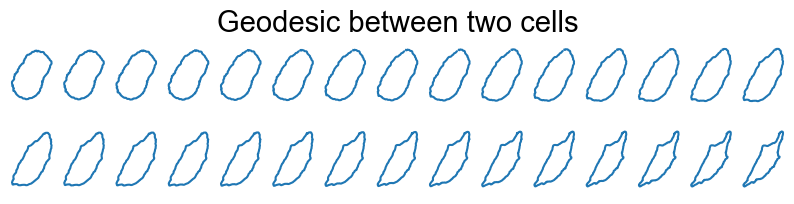

In [21]:
fig = plt.figure(figsize=(10, 2))
plt.title("Geodesic between two cells")
plt.axis("off")

for i, curve in enumerate(geod_points):
    fig.add_subplot(2, n_times // 2, i + 1)
    plt.plot(curve[:, 0], curve[:, 1])
    plt.axis("equal")
    plt.axis("off")
plt.savefig("geodesic_light_blue.svg")

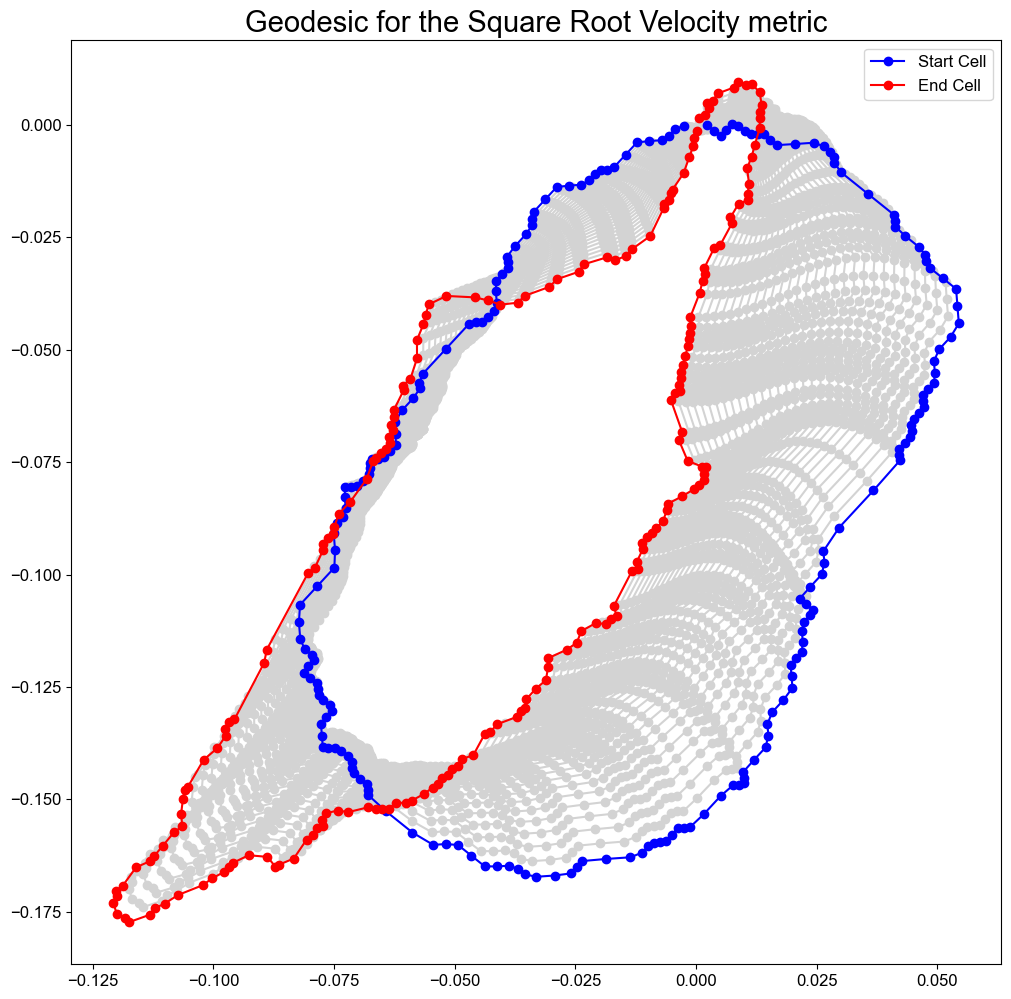

In [22]:
plt.figure(figsize=(12, 12))
for i in range(1, n_times - 1):
    plt.plot(geod_points[i, :, 0], geod_points[i, :, 1], "o-", color="lightgrey")
plt.plot(geod_points[0, :, 0], geod_points[0, :, 1], "o-b", label="Start Cell")
plt.plot(geod_points[-1, :, 0], geod_points[-1, :, 1], "o-r", label="End Cell")

plt.title("Geodesic for the Square Root Velocity metric")
plt.legend()
plt.savefig("geodesic_blue_red.svg");

In [23]:
cell_shapes_list = []
for treatment in TREATMENTS:
    for line in LINES:
        cell_shapes_list.extend(ds_align[treatment][line])

cell_shapes = gs.array(cell_shapes_list)
print(cell_shapes.shape)

(650, 200, 2)


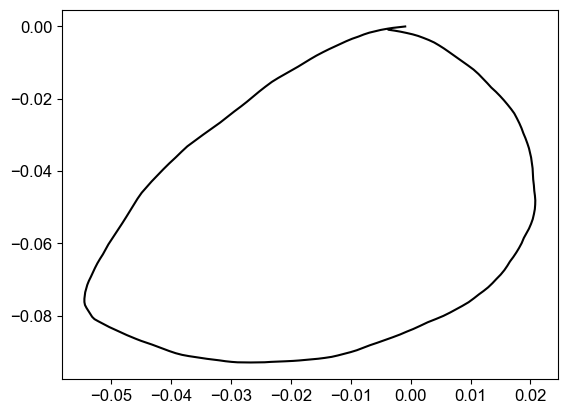

In [24]:
from geomstats.learning.frechet_mean import FrechetMean

mean = FrechetMean(CURVES_SPACE_SRV)

cell_shapes_at_origin = CURVES_SPACE_SRV.projection(cell_shapes)
mean.fit(cell_shapes_at_origin[:500])

mean_estimate = mean.estimate_

plt.plot(mean_estimate[:, 0], mean_estimate[:, 1], "black");

In [25]:
print(gs.sum(gs.isnan(mean_estimate)))
mean_estimate_clean = mean_estimate[~gs.isnan(gs.sum(mean_estimate, axis=1)), :]
print(mean_estimate_clean.shape)
mean_estimate_clean = interpolate(mean_estimate_clean, k_sampling_points - 1)
print(gs.sum(gs.isnan(mean_estimate_clean)))
print(mean_estimate_clean.shape)

0
(199, 2)
0
(199, 2)


(650, 199, 2)


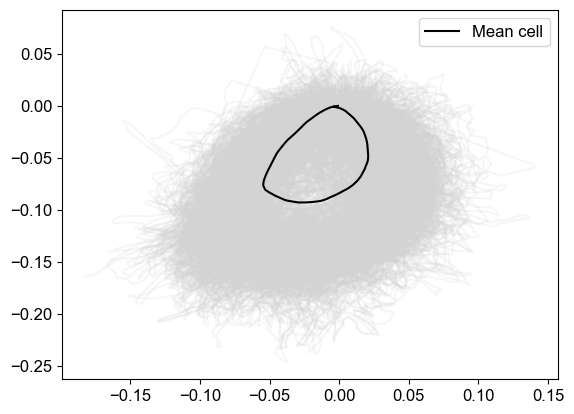

In [26]:
print(cell_shapes_at_origin.shape)
for cell_at_origin in cell_shapes_at_origin:
    plt.plot(cell_at_origin[:, 0], cell_at_origin[:, 1], "lightgrey", alpha=0.2)

plt.plot(
    mean_estimate_clean[:, 0], mean_estimate_clean[:, 1], "black", label="Mean cell"
)
plt.legend(fontsize=12);

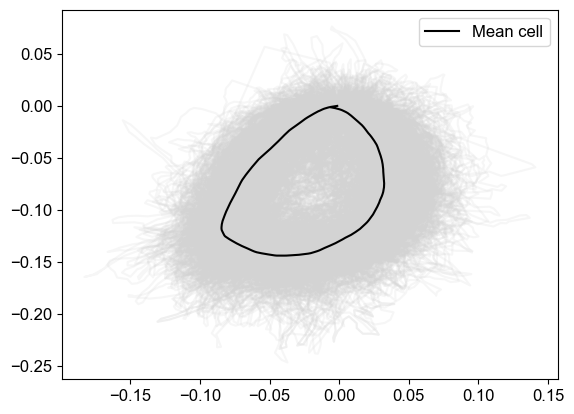

In [27]:
mean_estimate_aligned = 1.55 * mean_estimate_clean

for cell_at_origin in cell_shapes_at_origin:
    plt.plot(cell_at_origin[:, 0], cell_at_origin[:, 1], "lightgrey", alpha=0.2)

plt.plot(
    mean_estimate_aligned[:, 0], mean_estimate_aligned[:, 1], "black", label="Mean cell"
)
plt.legend(fontsize=12);

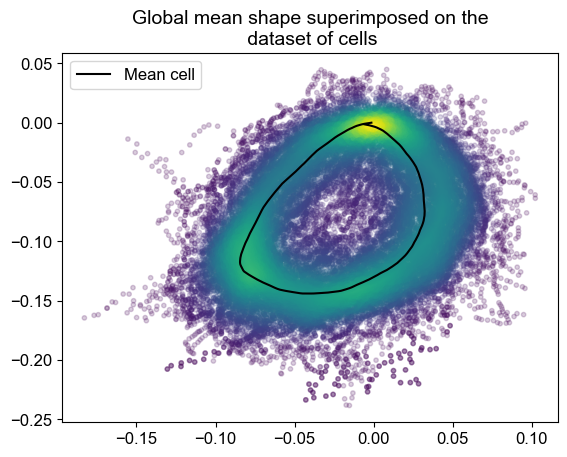

In [28]:
from scipy.stats import gaussian_kde

cells_to_plot = cell_shapes_at_origin[
    gs.random.randint(len(cell_shapes_at_origin), size=200)
]
points_to_plot = cells_to_plot.reshape(-1, 2)

z = gaussian_kde(points_to_plot.T)(points_to_plot.T)
z_norm = z / z.max()

plt.scatter(points_to_plot[:, 0], points_to_plot[:, 1], alpha=0.2, c=z_norm, s=10)
plt.plot(
    mean_estimate_aligned[:, 0],
    mean_estimate_aligned[:, 1],
    "black",
    label="Mean cell",
)
plt.legend(fontsize=12)
plt.title("Global mean shape superimposed on the\n dataset of cells", fontsize=14)

plt.savefig("global_mean_shape.svg")

In [29]:
dists_to_global_mean = apply_func_to_ds(
    ds_align,
    func=lambda x: CURVES_SPACE_SRV.metric.dist(
        CURVES_SPACE_SRV.projection(x), mean_estimate_aligned
    ),
)

dists_to_global_mean_list = []
for t in TREATMENTS:
    for line in LINES:
        dists_to_global_mean_list.extend(dists_to_global_mean[t][line])

In [30]:
dists_to_global_mean_list[:5]

[0.4946340823138246,
 0.4593100615837322,
 0.39849340162938046,
 0.41134976167008064,
 0.37043235963232785]

In [31]:
gs.where(gs.isnan(dists_to_global_mean_list))

(array([], dtype=int64),)

In [32]:
min_dists = min(dists_to_global_mean_list)
max_dists = max(dists_to_global_mean_list)
print(min_dists, max_dists)

0.32850164542970456 1.268598391470776


In [33]:
xx = gs.linspace(gs.floor(min_dists), gs.ceil(max_dists), 100)

In [34]:
from scipy import stats

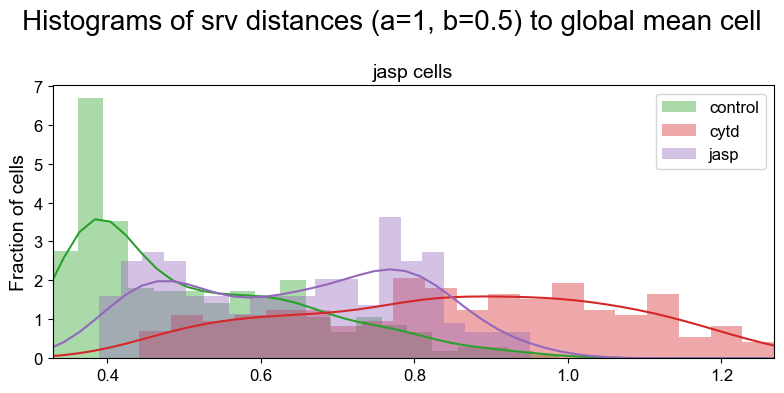

In [35]:
fig, axs = plt.subplots(1, sharex=True, sharey=True, tight_layout=True, figsize=(8, 4))

for i, treatment in enumerate(TREATMENTS):
    distances = []
    for j, line in enumerate(LINES):
        distances.extend(
            dists_to_global_mean[treatment][line][
                ~gs.isnan(dists_to_global_mean[treatment][line])
            ]
        )
    color = "C" + str(2 + i)
    axs.hist(distances, bins=20, alpha=0.4, density=True, color=color, label=treatment)
    kde = stats.gaussian_kde(distances)
    axs.plot(xx, kde(xx), color=color)
    axs.set_xlim((min_dists, max_dists))
    axs.legend(fontsize=12)

    axs.set_title(f"{treatment} cells", fontsize=14)
    axs.set_ylabel("Fraction of cells", fontsize=14)


fig.suptitle(
    "Histograms of srv distances (a=1, b=0.5) to global mean cell", fontsize=20
)
plt.savefig("dist_to_global_mean_per_treatment2.svg")

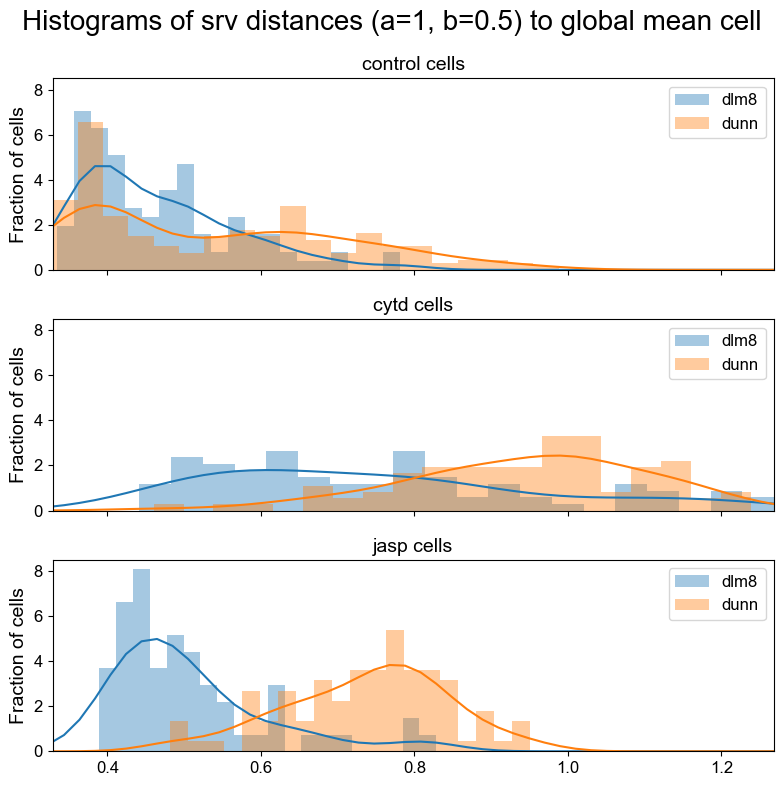

In [36]:
fig, axs = plt.subplots(3, sharex=True, sharey=True, tight_layout=True, figsize=(8, 8))

axs[0].set_xlim((min_dists, max_dists))
for i, treatment in enumerate(TREATMENTS):
    for j, line in enumerate(LINES):
        distances = dists_to_global_mean[treatment][line][
            ~gs.isnan(dists_to_global_mean[treatment][line])
        ]
        color = f"C{j}"
        axs[i].hist(
            distances, bins=20, alpha=0.4, density=True, color=color, label=line
        )
        kde = stats.gaussian_kde(distances)
        axs[i].plot(xx, kde(xx), color=color)

    axs[i].set_title(f"{treatment} cells", fontsize=14)
    axs[i].set_ylabel("Fraction of cells", fontsize=14)
    axs[i].legend(fontsize=12)

fig.suptitle(
    "Histograms of srv distances (a=1, b=0.5) to global mean cell", fontsize=20
)
plt.savefig("dist_to_global_mean_per_class2.svg")

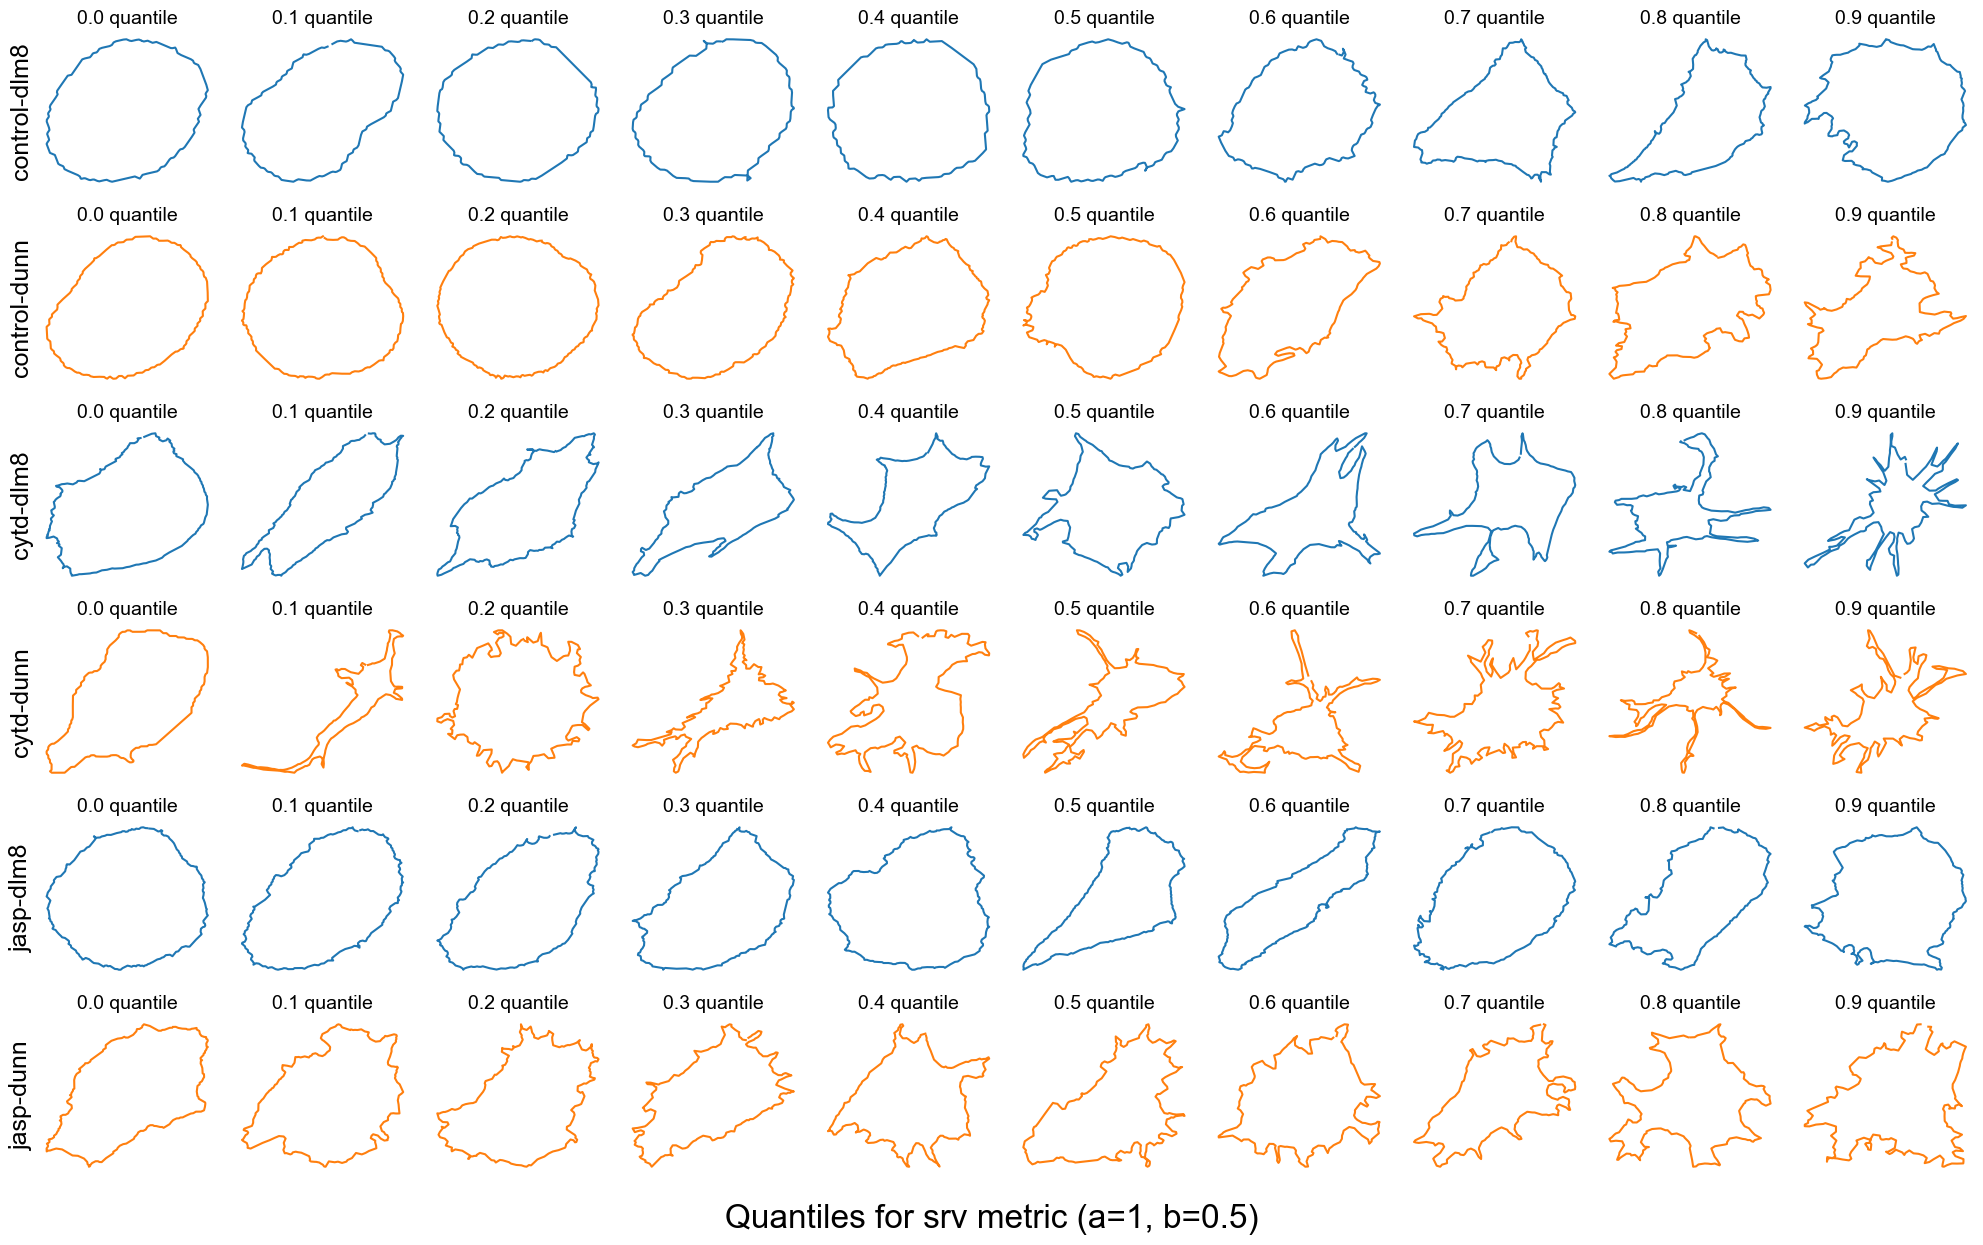

In [37]:
n_quantiles = 10
fig, axes = plt.subplots(
    nrows=len(TREATMENTS) * len(LINES),
    ncols=n_quantiles,
    figsize=(20, 2 * len(LINES) * len(TREATMENTS)),
)

for i, treatment in enumerate(TREATMENTS):
    for j, line in enumerate(LINES):
        dists_list = dists_to_global_mean[treatment][line]
        dists_list = [d + 0.0001 * gs.random.rand(1)[0] for d in dists_list]
        cells_list = list(ds_align[treatment][line])
        assert len(dists_list) == len(dists_list)
        n_cells = len(dists_list)

        zipped_lists = zip(dists_list, cells_list)
        sorted_pairs = sorted(zipped_lists)

        tuples = zip(*sorted_pairs)
        sorted_dists_list, sorted_cells_list = [list(t) for t in tuples]
        for i_quantile in range(n_quantiles):
            quantile = int(0.1 * n_cells * i_quantile)
            one_cell = sorted_cells_list[quantile]
            ax = axes[2 * i + j, i_quantile]
            ax.plot(one_cell[:, 0], one_cell[:, 1], c=f"C{j}")
            ax.set_title(f"0.{i_quantile} quantile", fontsize=14)
            # ax.axis("off")
            # Turn off tick labels
            ax.set_yticklabels([])
            ax.set_xticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_visible(False)
            ax.spines["left"].set_visible(False)
            if i_quantile == 0:
                ax.set_ylabel(f"{treatment}-{line}", rotation=90, fontsize=18)
plt.tight_layout()
plt.suptitle("Quantiles for srv metric (a=1, b=0.5)", y=-0.01, fontsize=24)
plt.savefig("quantiles.svg")

In [38]:
from geomstats.geometry.discrete_curves import ElasticMetric

a = 3
b = 1

CURVES_SPACE_ELASTIC = DiscreteCurvesStartingAtOrigin(
    ambient_dim=2, k_sampling_points=200, equip=False
)
CURVES_SPACE_ELASTIC.equip_with_metric(ElasticMetric, a=a, b=b)

In [39]:
elastic_dists_to_global_mean = apply_func_to_ds(
    ds_align,
    func=lambda x: CURVES_SPACE_ELASTIC.metric.dist(
        CURVES_SPACE_ELASTIC.projection(x), mean_estimate_aligned
    ),
)

elastic_dists_to_global_mean_list = []
for t in TREATMENTS:
    for line in LINES:
        elastic_dists_to_global_mean_list.extend(elastic_dists_to_global_mean[t][line])

In [40]:
elastic_min_dists = min(elastic_dists_to_global_mean_list)
elastic_max_dists = max(elastic_dists_to_global_mean_list)
print(elastic_min_dists, elastic_max_dists)
elastic_xx = gs.linspace(gs.floor(elastic_min_dists), gs.ceil(elastic_max_dists), 100)

0.8661587438880228 3.103265148539346


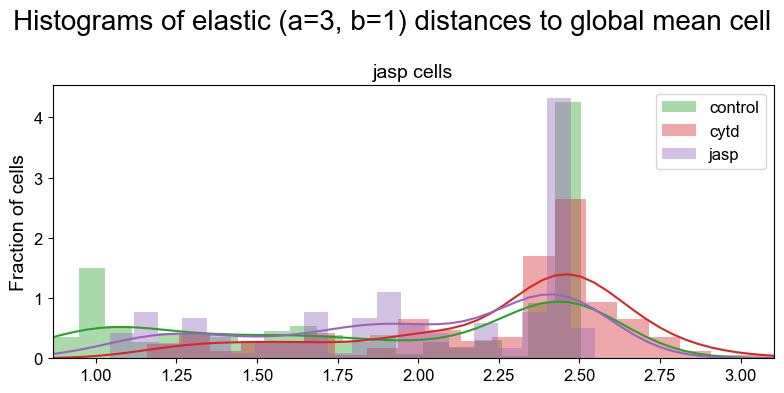

In [41]:
fig, axs = plt.subplots(1, sharex=True, sharey=True, tight_layout=True, figsize=(8, 4))

for i, treatment in enumerate(TREATMENTS):
    distances = []
    for j, line in enumerate(LINES):
        distances.extend(
            elastic_dists_to_global_mean[treatment][line][
                ~gs.isnan(elastic_dists_to_global_mean[treatment][line])
            ]
        )
    color = "C" + str(2 + i)
    axs.hist(distances, bins=20, alpha=0.4, density=True, color=color, label=treatment)
    kde = stats.gaussian_kde(distances)
    axs.plot(elastic_xx, kde(elastic_xx), color=color)
    axs.set_xlim((elastic_min_dists, elastic_max_dists))
    axs.legend(fontsize=12)

    axs.set_title(f"{treatment} cells", fontsize=14)
    axs.set_ylabel("Fraction of cells", fontsize=14)


fig.suptitle(
    f"Histograms of elastic (a={a}, b={b}) distances to global mean cell", fontsize=20
)
plt.savefig(f"dist_to_global_mean_per_treatment2_a{a}_b{b}.svg")

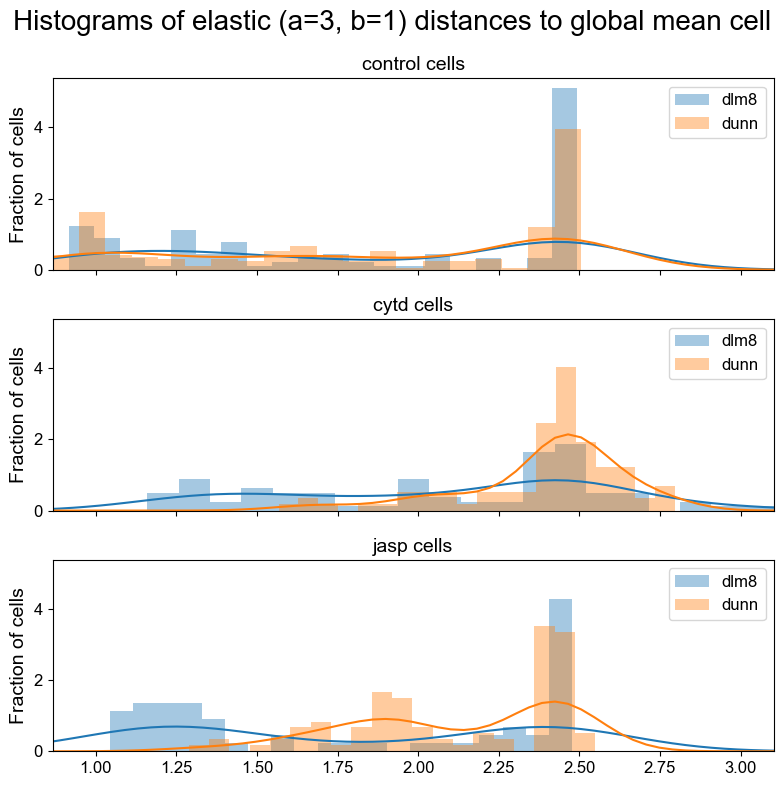

In [42]:
fig, axs = plt.subplots(3, sharex=True, sharey=True, tight_layout=True, figsize=(8, 8))

axs[0].set_xlim((elastic_min_dists, elastic_max_dists))
for i, treatment in enumerate(TREATMENTS):
    for j, line in enumerate(LINES):
        distances = elastic_dists_to_global_mean[treatment][line][
            ~gs.isnan(elastic_dists_to_global_mean[treatment][line])
        ]
        color = f"C{j}"
        axs[i].hist(
            distances, bins=20, alpha=0.4, density=True, color=color, label=line
        )
        kde = stats.gaussian_kde(distances)
        axs[i].plot(elastic_xx, kde(elastic_xx), color=color)

    axs[i].set_title(f"{treatment} cells", fontsize=14)
    axs[i].set_ylabel("Fraction of cells", fontsize=14)
    axs[i].legend(fontsize=12)

fig.suptitle(
    f"Histograms of elastic (a={a}, b={b}) distances to global mean cell", fontsize=20
)
plt.savefig(f"dist_to_global_mean_per_class2_a{a}_b{b}.svg")

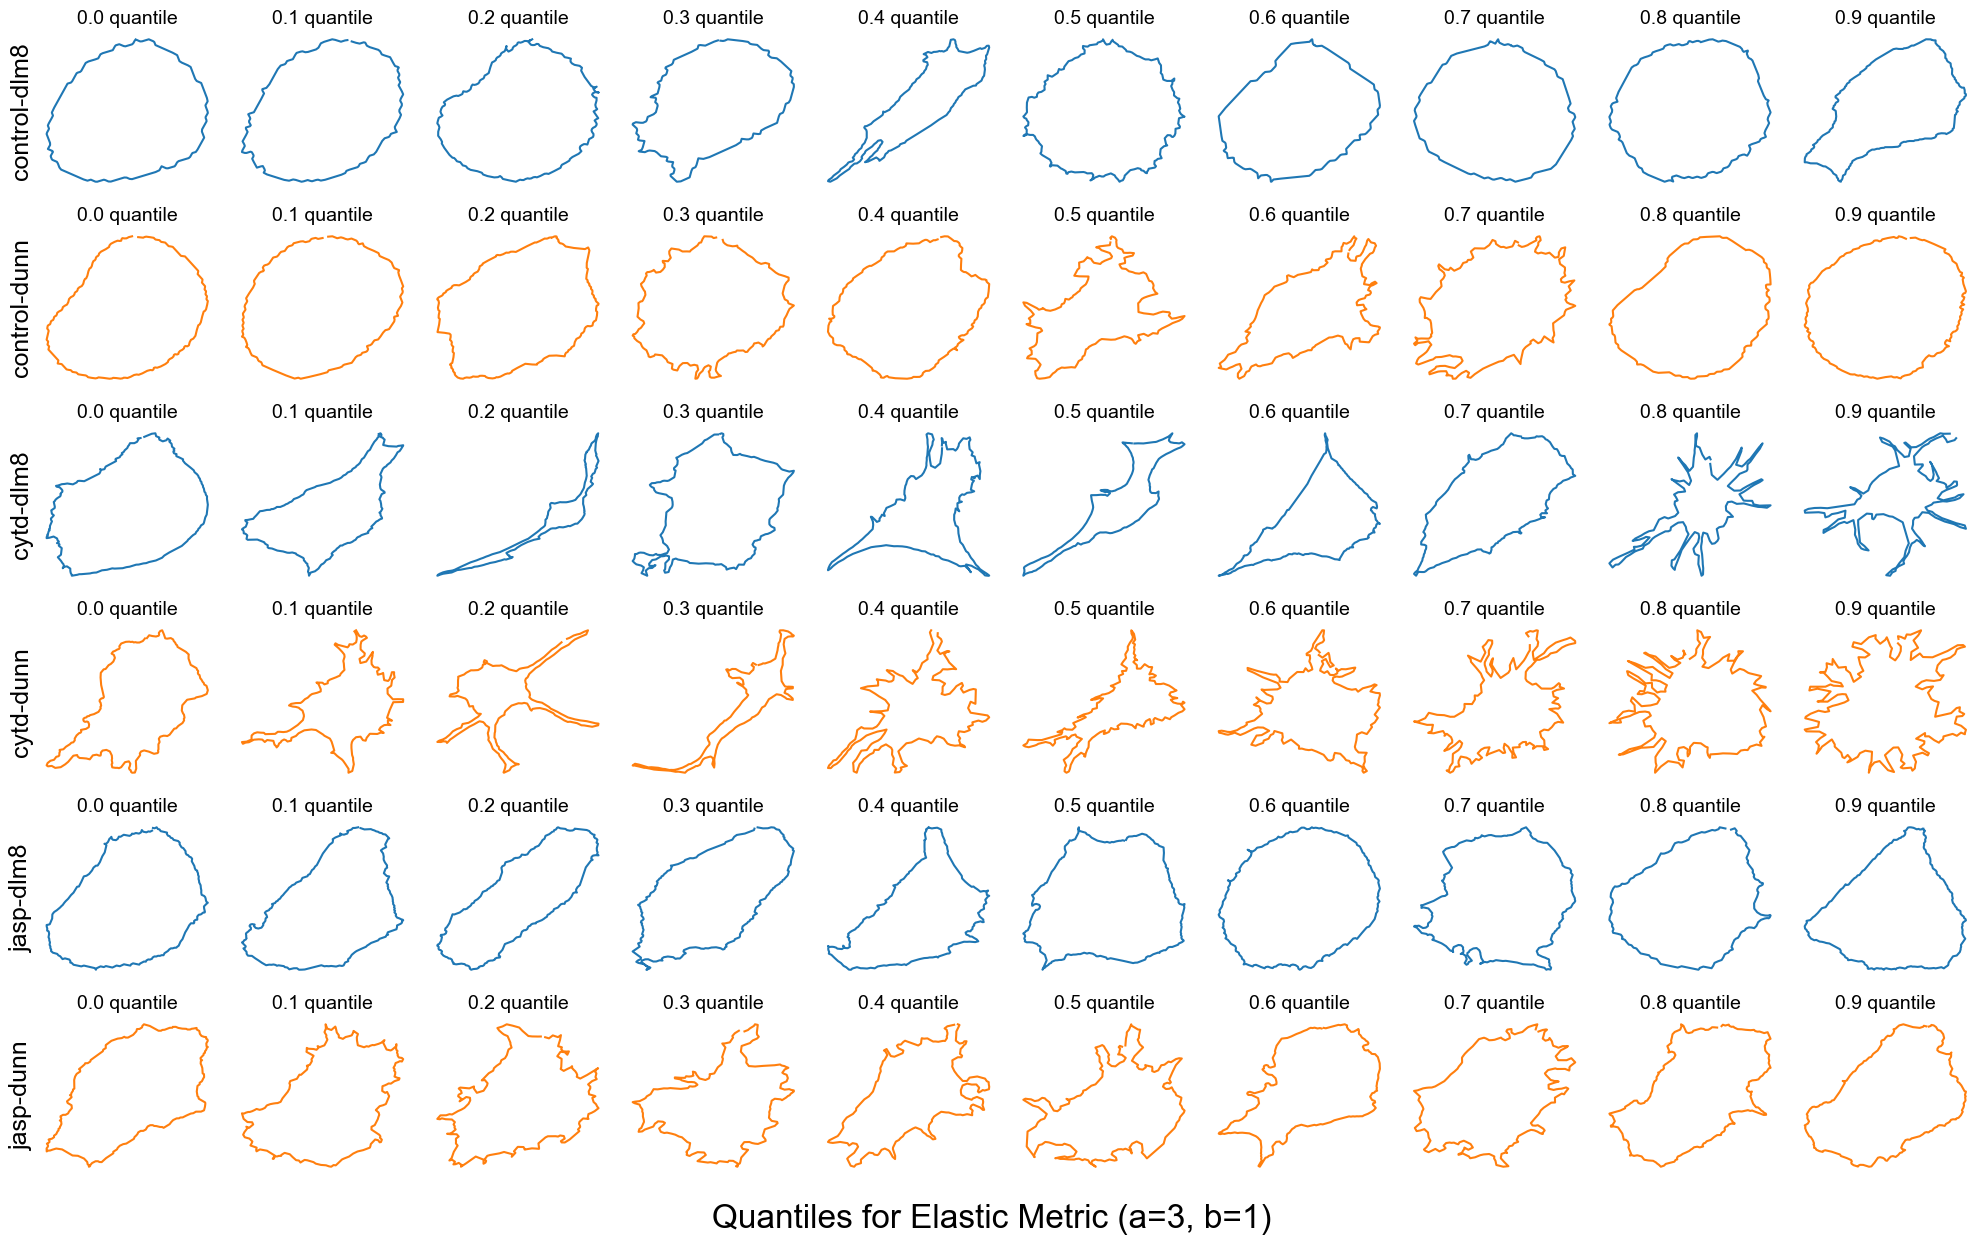

In [43]:
fig, axes = plt.subplots(
    nrows=len(TREATMENTS) * len(LINES),
    ncols=n_quantiles,
    figsize=(20, 2 * len(LINES) * len(TREATMENTS)),
)

for i, treatment in enumerate(TREATMENTS):
    for j, line in enumerate(LINES):
        elastic_dists_list = elastic_dists_to_global_mean[treatment][line]
        elastic_dists_list = [
            d + 0.0001 * gs.random.rand(1)[0] for d in elastic_dists_list
        ]
        cells_list = list(ds_align[treatment][line])
        assert len(elastic_dists_list) == len(elastic_dists_list)
        n_cells = len(elastic_dists_list)

        zipped_lists = zip(elastic_dists_list, cells_list)
        sorted_pairs = sorted(zipped_lists)

        tuples = zip(*sorted_pairs)
        sorted_dists_list, sorted_cells_list = [list(t) for t in tuples]
        for i_quantile in range(n_quantiles):
            quantile = int(0.1 * n_cells * i_quantile)
            one_cell = sorted_cells_list[quantile]
            ax = axes[2 * i + j, i_quantile]
            ax.plot(one_cell[:, 0], one_cell[:, 1], c=f"C{j}")
            ax.set_title(f"0.{i_quantile} quantile", fontsize=14)
            # ax.axis("off")
            # Turn off tick labels
            ax.set_yticklabels([])
            ax.set_xticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_visible(False)
            ax.spines["left"].set_visible(False)
            if i_quantile == 0:
                ax.set_ylabel(f"{treatment}-{line}", rotation=90, fontsize=18)
plt.tight_layout()
plt.suptitle(f"Quantiles for Elastic Metric (a={a}, b={b})", y=-0.01, fontsize=24)
plt.savefig(f"elastic_quantiles_a{a}_b{b}.svg")

In [44]:
import scipy

In [45]:
line_1, line_2 = LINES

print(f"\n --- Test equality of means: {line_1} vs {line_2}")
dists_1 = []
for treatment_1 in TREATMENTS:
    dists_1.extend(dists_to_global_mean[treatment_1][line_1])
dists_1 = gs.array(dists_1)

dists_2 = []
for treatment_2 in TREATMENTS:
    dists_2.extend(dists_to_global_mean[treatment_2][line_2])
dist_2 = gs.array(dists_2)

display(scipy.stats.ttest_ind(dists_1, dists_2, equal_var=False))


 --- Test equality of means: dlm8 vs dunn


TtestResult(statistic=-7.1196419270836255, pvalue=3.0954021594097e-12, df=601.8218123340728)

In [46]:
from itertools import combinations

count = 0


for two_treatments in combinations(TREATMENTS, 2):
    treatment_1, treatment_2 = two_treatments

    print(f"\n --- Test equality of means: {treatment_1} vs {treatment_2}")
    dists_1 = []
    for line_1 in LINES:
        dists_1.extend(dists_to_global_mean[treatment_1][line_1])
    dists_1 = gs.array(dists_1)

    dists_2 = []
    for line_2 in LINES:
        dists_2.extend(dists_to_global_mean[treatment_2][line_2])
    dist_2 = gs.array(dists_2)

    display(scipy.stats.ttest_ind(dists_1, dists_2, equal_var=False))
    count += 1
print(
    f"!! Correct for multiple hypothesis testing with Bonferroni correction,"
    f" by multiplying the p-values by {count} "
)


 --- Test equality of means: control vs cytd


TtestResult(statistic=-18.91033116839886, pvalue=1.5942047693178156e-51, df=272.537293447805)


 --- Test equality of means: control vs jasp


TtestResult(statistic=-9.029282700140122, pvalue=2.018213894034308e-17, df=304.63782613884155)


 --- Test equality of means: cytd vs jasp


TtestResult(statistic=10.293250508487542, pvalue=1.2621209911040088e-21, df=316.70165636925606)

!! Correct for multiple hypothesis testing with Bonferroni correction, by multiplying the p-values by 3 


In [48]:
TREATMENT_LINE_CLASSES = set([(t, line) for t in TREATMENTS for line in LINES])

In [49]:
count = 0

for two_classes in combinations(TREATMENT_LINE_CLASSES, 2):
    class_1, class_2 = two_classes
    treatment_1, line_1 = class_1
    treatment_2, line_2 = class_2
    print(
        f"\n --- Test equality of means: {treatment_1}-{line_1} vs {treatment_2}-{line_2}"
    )
    display(
        scipy.stats.ttest_ind(
            dists_to_global_mean[treatment_1][line_1],
            dists_to_global_mean[treatment_2][line_2],
            equal_var=False,
        )
    )
    count += 1
print(
    f"!! Correct for multiple hypothesis testing with Bonferroni correction,"
    f" by multiplying the p-values by {count} "
)


 --- Test equality of means: jasp-dlm8 vs cytd-dunn


TtestResult(statistic=-21.22532840794736, pvalue=1.9868071249630862e-47, df=152.8507694252556)


 --- Test equality of means: jasp-dlm8 vs jasp-dunn


TtestResult(statistic=-13.823886158709499, pvalue=1.3180986251513484e-27, df=134.6358168194752)


 --- Test equality of means: jasp-dlm8 vs control-dunn


...


 --- Test equality of means: control-dunn vs control-dlm8


TtestResult(statistic=5.024339985563299, pvalue=8.483653891852102e-07, df=314.8644756653143)


 --- Test equality of means: cytd-dlm8 vs control-dlm8


TtestResult(statistic=11.070853589195252, pvalue=2.4267876823265633e-19, df=105.01458635645852)

!! Correct for multiple hypothesis testing with Bonferroni correction, by multiplying the p-values by 15 


In [50]:
mean_estimator = FrechetMean(CURVES_SPACE_SRV)

In [51]:
mean_treatment_cells = {}
for treatment in TREATMENTS:
    treatment_cells = []
    for line in LINES:
        treatment_cells.extend(ds_align[treatment][line])
    mean_estimator.fit(CURVES_SPACE_SRV.projection(gs.array(treatment_cells[:30])))
    mean_treatment_cells[treatment] = mean_estimator.estimate_

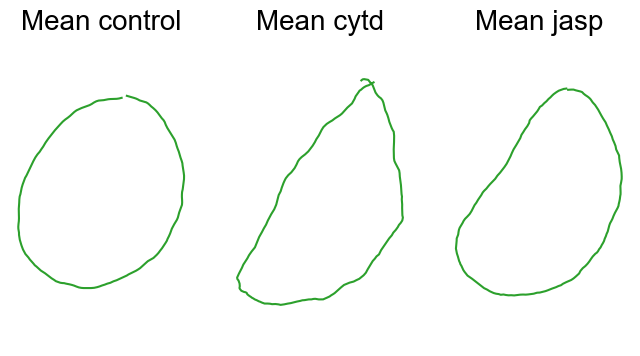

In [52]:
fig = plt.figure(figsize=(8, 4))
count = 1
for treatment in TREATMENTS:
    mean_cell = mean_treatment_cells[treatment]
    fig.add_subplot(1, len(TREATMENTS), count)
    count += 1
    plt.plot(mean_cell[:, 0], mean_cell[:, 1], color="C2")
    plt.axis("equal")
    plt.axis("off")
    plt.title(f"Mean {treatment}", fontsize=20)
plt.savefig("cancer_mean_treatment_cells.svg")

In [53]:
mean_line_cells = {}
for line in LINES:
    line_cells = []
    for treatment in TREATMENTS:
        line_cells.extend(ds_align[treatment][line])
    mean_estimator.fit(CURVES_SPACE_SRV.projection(gs.array(line_cells[:225])))
    mean_line_cells[line] = mean_estimator.estimate_

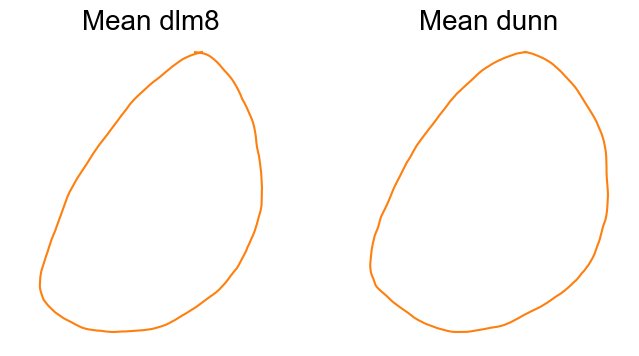

In [54]:
fig = plt.figure(figsize=(8, 4))
count = 1
for line in LINES:
    mean_cell = mean_line_cells[line]
    fig.add_subplot(1, len(LINES), count)
    count += 1
    plt.plot(mean_cell[:, 0], mean_cell[:, 1], color="C1")
    plt.axis("equal")
    plt.axis("off")
    plt.title(f"Mean {line}", fontsize=20)
plt.savefig("cancer_mean_line_cells.svg")

In [55]:
mean_cells = {}
for treatment in TREATMENTS:
    mean_cells[treatment] = {}
    for line in LINES:
        mean_estimator.fit(CURVES_SPACE_SRV.projection(ds_align[treatment][line][:20]))
        mean_cells[treatment][line] = mean_estimator.estimate_

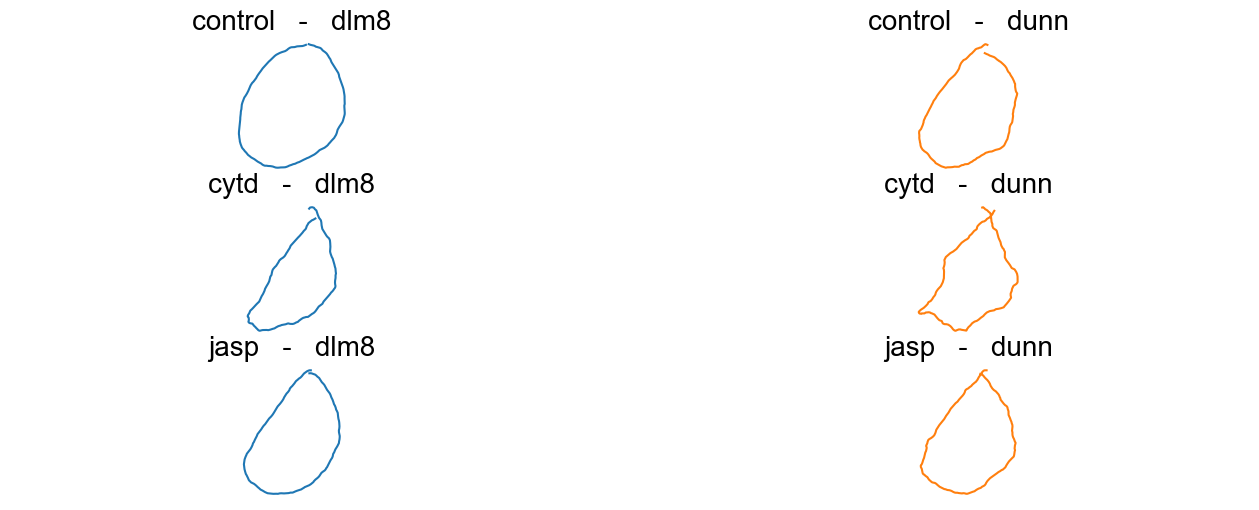

In [56]:
fig = plt.figure(figsize=(16, 6))
count = 1
for treatment in TREATMENTS:
    for j, line in enumerate(LINES):
        mean_cell = mean_cells[treatment][line]
        fig.add_subplot(len(TREATMENTS), len(LINES), count)
        count += 1
        plt.plot(mean_cell[:, 0], mean_cell[:, 1], color=f"C{j}")
        plt.axis("equal")
        plt.axis("off")
        plt.title(f"{treatment}   -   {line}", fontsize=20)
plt.savefig("cancer_mean_cells.svg")

In [57]:
dists_to_own_mean = {}
nan_ids = {}
for treatment in TREATMENTS:
    dists_to_own_mean[treatment] = {}
    nan_ids[treatment] = {}
    for line in LINES:
        dists = []
        ids = []
        for i_curve, curve in enumerate(ds_align[treatment][line]):
            one_dist = CURVES_SPACE_SRV.metric.dist(
                CURVES_SPACE_SRV.projection(curve), mean_cells[treatment][line]
            )
            if ~gs.isnan(one_dist):
                dists.append(one_dist)
            else:
                ids.append(i_curve)
        dists_to_own_mean[treatment][line] = dists
        nan_ids[treatment][line] = ids

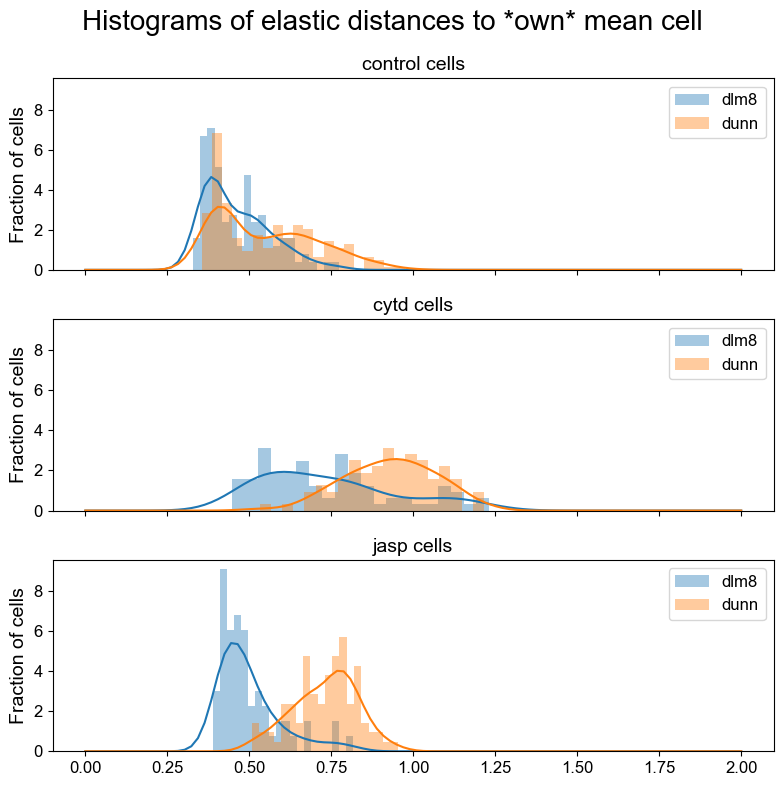

In [58]:
fig, axs = plt.subplots(3, sharex=True, sharey=True, tight_layout=True, figsize=(8, 8))

for i, treatment in enumerate(TREATMENTS):
    for j, line in enumerate(LINES):
        distances = dists_to_own_mean[treatment][line]
        color = f"C{j}"
        axs[i].hist(
            distances, bins=20, alpha=0.4, density=True, color=color, label=line
        )
        kde = stats.gaussian_kde(distances)
        axs[i].plot(xx, kde(xx), color=color)

    axs[i].set_title(f"{treatment} cells", fontsize=14)
    axs[i].set_ylabel("Fraction of cells", fontsize=14)
    axs[i].legend(fontsize=12)

fig.suptitle("Histograms of elastic distances to *own* mean cell", fontsize=20)
plt.savefig("dist_to_own_mean.svg")

This section adds two conceptual changes to the tutorial:

1. Balanced subgroup analysis:
- Build a balanced dataset with the same number of cells per treatment-line class.
- Recompute a global mean shape and distances to it.
- Compare treatment groups under reduced class-imbalance effects.

2. Metric-sensitivity analysis:
- Compare several elastic metrics by varying $(a,b)$.
- Quantify how treatment separation changes with the metric.

These additions are intended to make conclusions more robust and easier to interpret.

In [59]:
### Extension 1: balanced subgroup analysis + metric sensitivity
import numpy as np
from scipy import stats
from geomstats.geometry.discrete_curves import ElasticMetric, DiscreteCurvesStartingAtOrigin
from geomstats.learning.frechet_mean import FrechetMean

# Reproducibility for balanced subsampling
gs.random.seed(2026)

# Build balanced subset across treatment-line classes
class_sizes = {
    (treatment, line): len(ds_align[treatment][line])
    for treatment in TREATMENTS
    for line in LINES
}
min_class_size = min(class_sizes.values())

balanced_ds = {treatment: {} for treatment in TREATMENTS}
for treatment in TREATMENTS:
    for line in LINES:
        cells_list = ds_align[treatment][line]
        ids = gs.random.choice(len(cells_list), size=min_class_size, replace=False)
        balanced_ds[treatment][line] = gs.array([cells_list[int(i)] for i in ids])

# Flatten balanced cells and compute balanced global mean shape (SRV metric)
balanced_cells = []
for treatment in TREATMENTS:
    for line in LINES:
        balanced_cells.extend(balanced_ds[treatment][line])
balanced_cells = gs.array(balanced_cells)

curves_srv = DiscreteCurvesStartingAtOrigin(ambient_dim=2, k_sampling_points=k_sampling_points)
balanced_cells_at_origin = curves_srv.projection(balanced_cells)

mean_estimator = FrechetMean(curves_srv)
mean_estimator.fit(balanced_cells_at_origin)
balanced_global_mean = mean_estimator.estimate_

# Compare metrics via treatment-level distance distributions to balanced global mean
metric_configs = [(1, 0.5), (2, 1), (3, 1)]
summary_rows = []

for a_val, b_val in metric_configs:
    curves_space = DiscreteCurvesStartingAtOrigin(
        ambient_dim=2, k_sampling_points=k_sampling_points, equip=False
    )
    curves_space.equip_with_metric(ElasticMetric, a=a_val, b=b_val)

    dists_per_treatment = {}
    for treatment in TREATMENTS:
        all_dists = []
        for line in LINES:
            class_cells = balanced_ds[treatment][line]
            for curve in class_cells:
                d = curves_space.metric.dist(
                    curves_space.projection(curve), balanced_global_mean
                )
                if not gs.isnan(d):
                    all_dists.append(float(d))
        dists_per_treatment[treatment] = np.array(all_dists)

    # Welch t-tests between treatments on balanced data
    t_control_cytd = stats.ttest_ind(
        dists_per_treatment['control'], dists_per_treatment['cytd'], equal_var=False
    )
    t_control_jasp = stats.ttest_ind(
        dists_per_treatment['control'], dists_per_treatment['jasp'], equal_var=False
    )
    t_cytd_jasp = stats.ttest_ind(
        dists_per_treatment['cytd'], dists_per_treatment['jasp'], equal_var=False
    )

    summary_rows.append(
        {
            'metric': f'Elastic(a={a_val}, b={b_val})',
            'control_mean': float(np.mean(dists_per_treatment['control'])),
            'cytd_mean': float(np.mean(dists_per_treatment['cytd'])),
            'jasp_mean': float(np.mean(dists_per_treatment['jasp'])),
            'p_control_vs_cytd': float(t_control_cytd.pvalue),
            'p_control_vs_jasp': float(t_control_jasp.pvalue),
            'p_cytd_vs_jasp': float(t_cytd_jasp.pvalue),
        }
    )

import pandas as pd
summary_df = pd.DataFrame(summary_rows)

print('Balanced analysis summary')
print(f'Min class size used per treatment-line: {min_class_size}')
print(f'Balanced total cells: {len(balanced_cells)}')
display(summary_df)

# Keep one compact ranked view by separation from control
summary_df['delta_cytd_minus_control'] = summary_df['cytd_mean'] - summary_df['control_mean']
summary_df['delta_jasp_minus_control'] = summary_df['jasp_mean'] - summary_df['control_mean']
ranked = summary_df.sort_values('delta_cytd_minus_control', ascending=False)
print('\nMetrics ranked by cytd-control separation:')
display(ranked[['metric', 'delta_cytd_minus_control', 'delta_jasp_minus_control', 'p_control_vs_cytd', 'p_control_vs_jasp']])

Balanced analysis summary
Min class size used per treatment-line: 62
Balanced total cells: 372


,metric,control_mean,cytd_mean,jasp_mean,p_control_vs_cytd,p_control_vs_jasp,p_cytd_vs_jasp
0,"Elastic(a=1, b=0.5)",0.513398,0.817161,0.615751,3.621633e-30,2.734296e-07,3.022978e-16
1,"Elastic(a=2, b=1)",1.026795,1.634322,1.231502,3.621633e-30,2.734296e-07,3.022978e-16
2,"Elastic(a=3, b=1)",1.783261,2.091527,1.822992,1.710496e-07,5.011345e-01,1.105504e-06



Metrics ranked by cytd-control separation:


,metric,delta_cytd_minus_control,delta_jasp_minus_control,p_control_vs_cytd,p_control_vs_jasp
1,"Elastic(a=2, b=1)",0.607527,0.204707,3.621633e-30,2.734296e-07
2,"Elastic(a=3, b=1)",0.308267,0.039731,1.710496e-07,5.011345e-01
0,"Elastic(a=1, b=0.5)",0.303763,0.102354,3.621633e-30,2.734296e-07


### Documentation of Changes

What changed conceptually:
- We controlled for class imbalance by balancing each treatment-line subgroup.
- We tested sensitivity of conclusions to metric hyperparameters $(a,b)$.
- We added quantitative treatment comparisons with Welch's t-tests.

How to interpret outcomes:
- If treatment differences remain significant after balancing, conclusions are more robust.
- If rankings change strongly with $(a,b)$, conclusions are metric-sensitive and should be reported with that caveat.